In [121]:
import numpy as np
import matplotlib.pyplot as plt

In [122]:
def simple_func(A: np.ndarray, b: np.ndarray, x: np.ndarray) -> int:
    return 0.5 * (x.T @ A @ x) + np.dot(b, x)

def simple_func_d(A: np.ndarray, b: np.ndarray, x: np.ndarray, k: int | None = None) -> int:
    if k is None:
        return np.array([np.dot(A[i], x) + b[i] for i in range(b.shape[0])])
    return np.dot(A[k], x) + b[k]

In [123]:
def gradient_descent_method(
    A: np.ndarray,
    b: np.ndarray,
    x0: np.ndarray,
    tol: float,
    max_iter: int,
) -> tuple[np.ndarray|None, list[np.ndarray], int]:
    """
    Метод градиентного спуска для минимизации функции
    
    Параметры:
    A : np.ndarray (n x n) - положительно определенная симметричная матрица
    b : np.ndarray (n,) - вектор линейной части
    x0 : np.ndarray (n,) - начальное приближение
    tol : float - tolerance для остановки (норма изменения x)
    max_iter : int - максимальное число итераций
    
    Возвращает:
    x_opt : np.ndarray - найденный минимум
    history : list - история значений x на каждой итерации
    iterations : int - количество итераций
    """
    alpha = 1.0
    n = len(b)
    x = x0.copy()
    history = [x.copy()]
    
    for iteration in range(max_iter):
        # Вычисляем градиент
        grad = simple_func_d(A,b,x)

        # Проверка сходимости по норме градиента
        if np.linalg.norm(grad) < tol:
            break

        # Обновляем x
        x = x - alpha * grad
        
        # Сохраняем историю
        history.append(x.copy())
    
    return x, history, iteration + 1

In [124]:
def coordinate_descent_method(
    A: np.ndarray,
    b: np.ndarray,
    x0: np.ndarray,
    tol: float,
    max_iter: int,
) -> tuple[np.ndarray|None, list[np.ndarray], int]:
    """
    Метод покоординатного спуска для минимизации функции
    https://studfile.net/preview/4084875/page:5/
    
    Параметры:
    A : np.ndarray (n x n) - положительно определенная симметричная матрица
    b : np.ndarray (n,) - вектор линейной части
    x0 : np.ndarray (n,) - начальное приближение
    tol : float - tolerance для остановки (норма изменения x)
    max_iter : int - максимальное число итераций
    
    Возвращает:
    x_opt : np.ndarray - найденный минимум
    history : list - история значений x на каждой итерации
    iterations : int - количество итераций
    """
    alpha = 0.1
    n = len(b)
    x = x0.copy()
    history = [x.copy()]

    
    for iteration in range(max_iter):
        x_prev = x.copy()
        for i in range(n):
            # Вычисляем частную производную по i-й координате
            grad_i = simple_func_d(A, b, x, i)
        
            step = alpha * grad_i
        
            # Обновляем i-ю координату
            x[i] -= step

        history.append(x.copy())
        
        # Проверка сходимости
        if np.linalg.norm(x - x_prev) < tol and np.linalg.norm(simple_func(A,b,x) - simple_func(A,b,x_prev)) < tol:
            break
    else:
        return None, history, iteration
    
    return x, history, iteration + 1

In [125]:
def plot_norm_history(
    history: list[np.ndarray],
    x_opt: np.ndarray,
    max_iter: int,
    name: str
) -> None:
    """
    Строит график нормы вектора на каждой итерации
    
    Параметры:
    history : list of np.ndarray - список векторов x на каждой итерации
    x_opt : np.ndarray - аналитический результат
    max_iter : int - максимально количество итераций
    name : str - имя графика
    """
    norms = [np.linalg.norm(x-x_opt) for x in history]
    # end_val = norms[-1]
    # if len(norms) < max_iter:
    #     norms += [end_val] * (max_iter - len(norms))
    
    # no_norms_x = [i for i in range(len(norms), max_iter)]
    # no_norms_y = [end_val for _ in range(max_iter - len(norms))]
    
    plt.figure(figsize=(20, 14))
    plt.plot(norms, '.', markersize=16, linewidth=6)
    plt.xlabel('Итерация', fontsize=12)
    plt.ylabel('Норма разности вектора ||x|| и аналитического результата', fontsize=12)
    plt.title(name, fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [126]:
def plot_norm_histories(
    histories: list[list[np.ndarray]],
    names: list[str],
    x_opt: np.ndarray,
    max_iter: int,
    name: str
) -> None:
    """
    Строит график нормы вектора на каждой итерации
    
    Параметры:
    history : list of np.ndarray - список векторов x на каждой итерации
    x_opt : np.ndarray - аналитический результат
    max_iter : int - максимально количество итераций
    name : str - имя графика
    """
    all_norms = [[np.linalg.norm(x-x_opt) for x in history] for history in histories]
    
    plt.figure(figsize=(20, 14))
    for name, norms in zip(names, all_norms):
        plt.plot(norms, '.', markersize=8, linewidth=1.5, label=name)
    plt.xlabel('Итерация', fontsize=12)
    plt.ylabel('Норма разности вектора ||x|| и аналитического результата', fontsize=12)
    plt.title(name, fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.show()
    plt.legend()

In [127]:
def show_results(
    A: np.ndarray,
    b: np.ndarray,
    x0: np.ndarray,
    tol: float = 1e-6,
    max_iter: int = 1000,
):
    """
    находит аналитический экстремум и строит график насколько быстро они сближаются
    
    Параметры:
    A : np.ndarray (n x n) - положительно определенная симметричная матрица
    b : np.ndarray (n,) - вектор линейной части
    x0 : np.ndarray (n,) - начальное приближение
    tol : float - tolerance для остановки (норма изменения x)
    max_iter : int - максимальное число итераций
    """
    
    A = A.astype(np.float64)
    b = b.astype(np.float64)
    x0 = x0.astype(np.float64)
    
    x_opt_analytical = np.linalg.solve(A, -b)
    # f_analytical = 0.5 * x_analytical @ A @ x_analytical + b @ x_analytical
    print(f"аналитический результат {x_opt_analytical}")
    
    x_opt_grad, hist_grad, iters_grad = gradient_descent_method(
        A, b, x0, tol=tol, max_iter=max_iter
    )
    x_opt_coord, hist_coord, iters_coord = coordinate_descent_method(
        A, b, x0, tol=tol, max_iter=max_iter
    )
    result_grad = (np.linalg.norm(x_opt_grad - x_opt_analytical))
    print(f"точность которой достиг метод градиентного спуска {result_grad}")
    plot_norm_history(hist_grad, x_opt_analytical, max_iter, "градиентный спуск")

    result_coord = (np.linalg.norm(x_opt_coord - x_opt_analytical))
    print(f"точность которой достиг метод покоординатного спуска {result_coord}")
    plot_norm_history(hist_coord, x_opt_analytical, max_iter, "покоординатный спуск")
    
    plot_norm_histories(
        [hist_grad, hist_coord],
        ["градиентный спуск", "покоординатный спуск"],
        x_opt_analytical,
        max_iter,
        "оба метода"
    )


аналитический результат [-0.66666667  1.66666667 -2.33333333]
точность которой достиг метод градиентного спуска nan


/tmp/ipykernel_5951/4137336740.py:37: RuntimeWarning: invalid value encountered in subtract
  x = x - alpha * grad


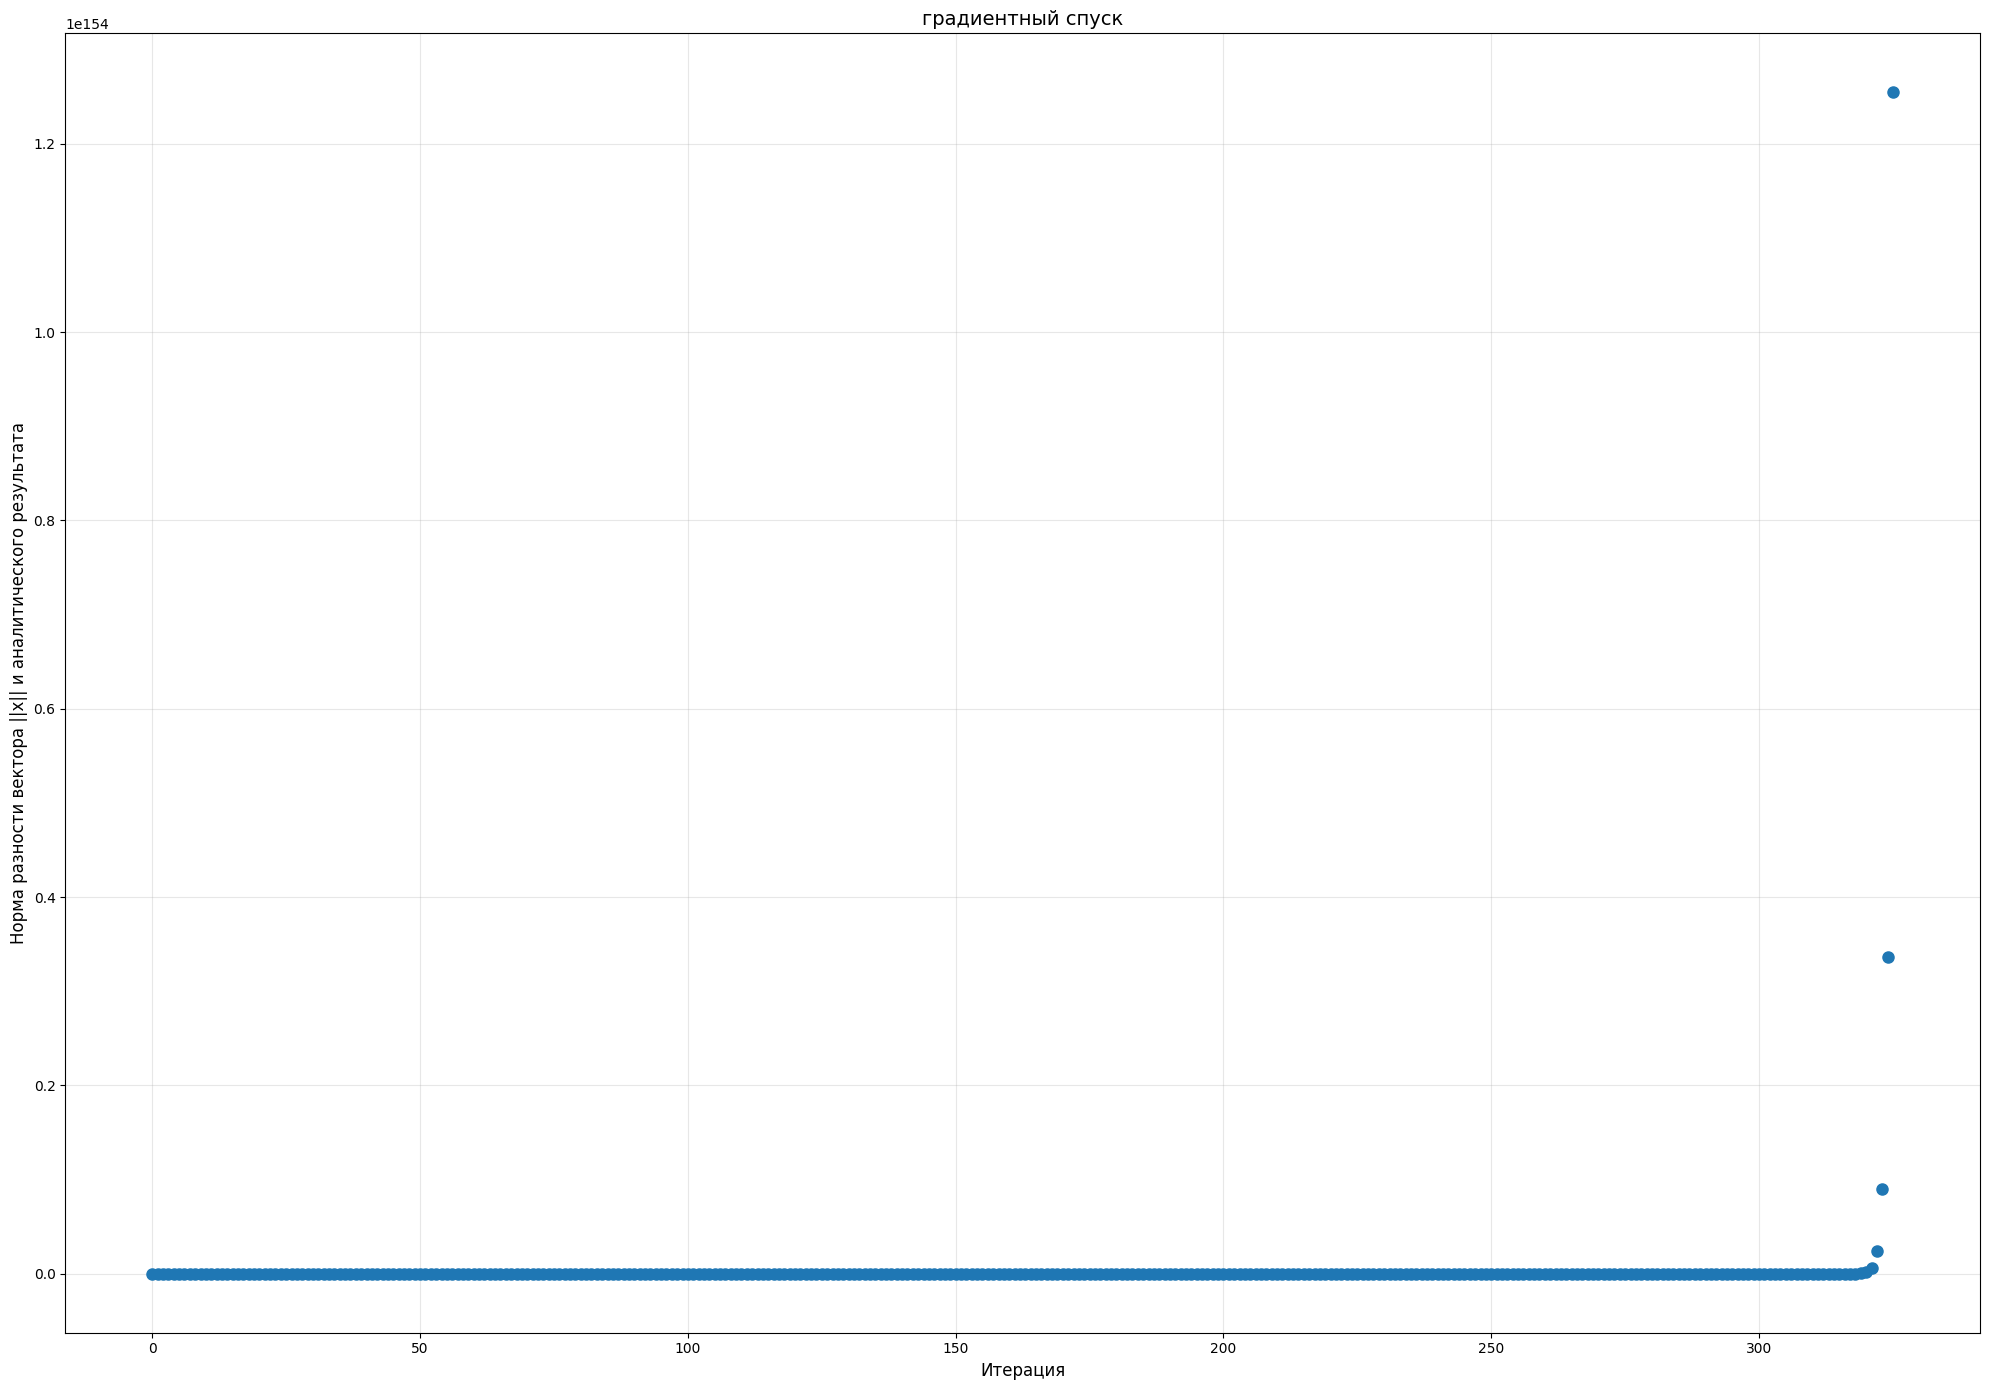

точность которой достиг метод покоординатного спуска 6.249244054359322e-06


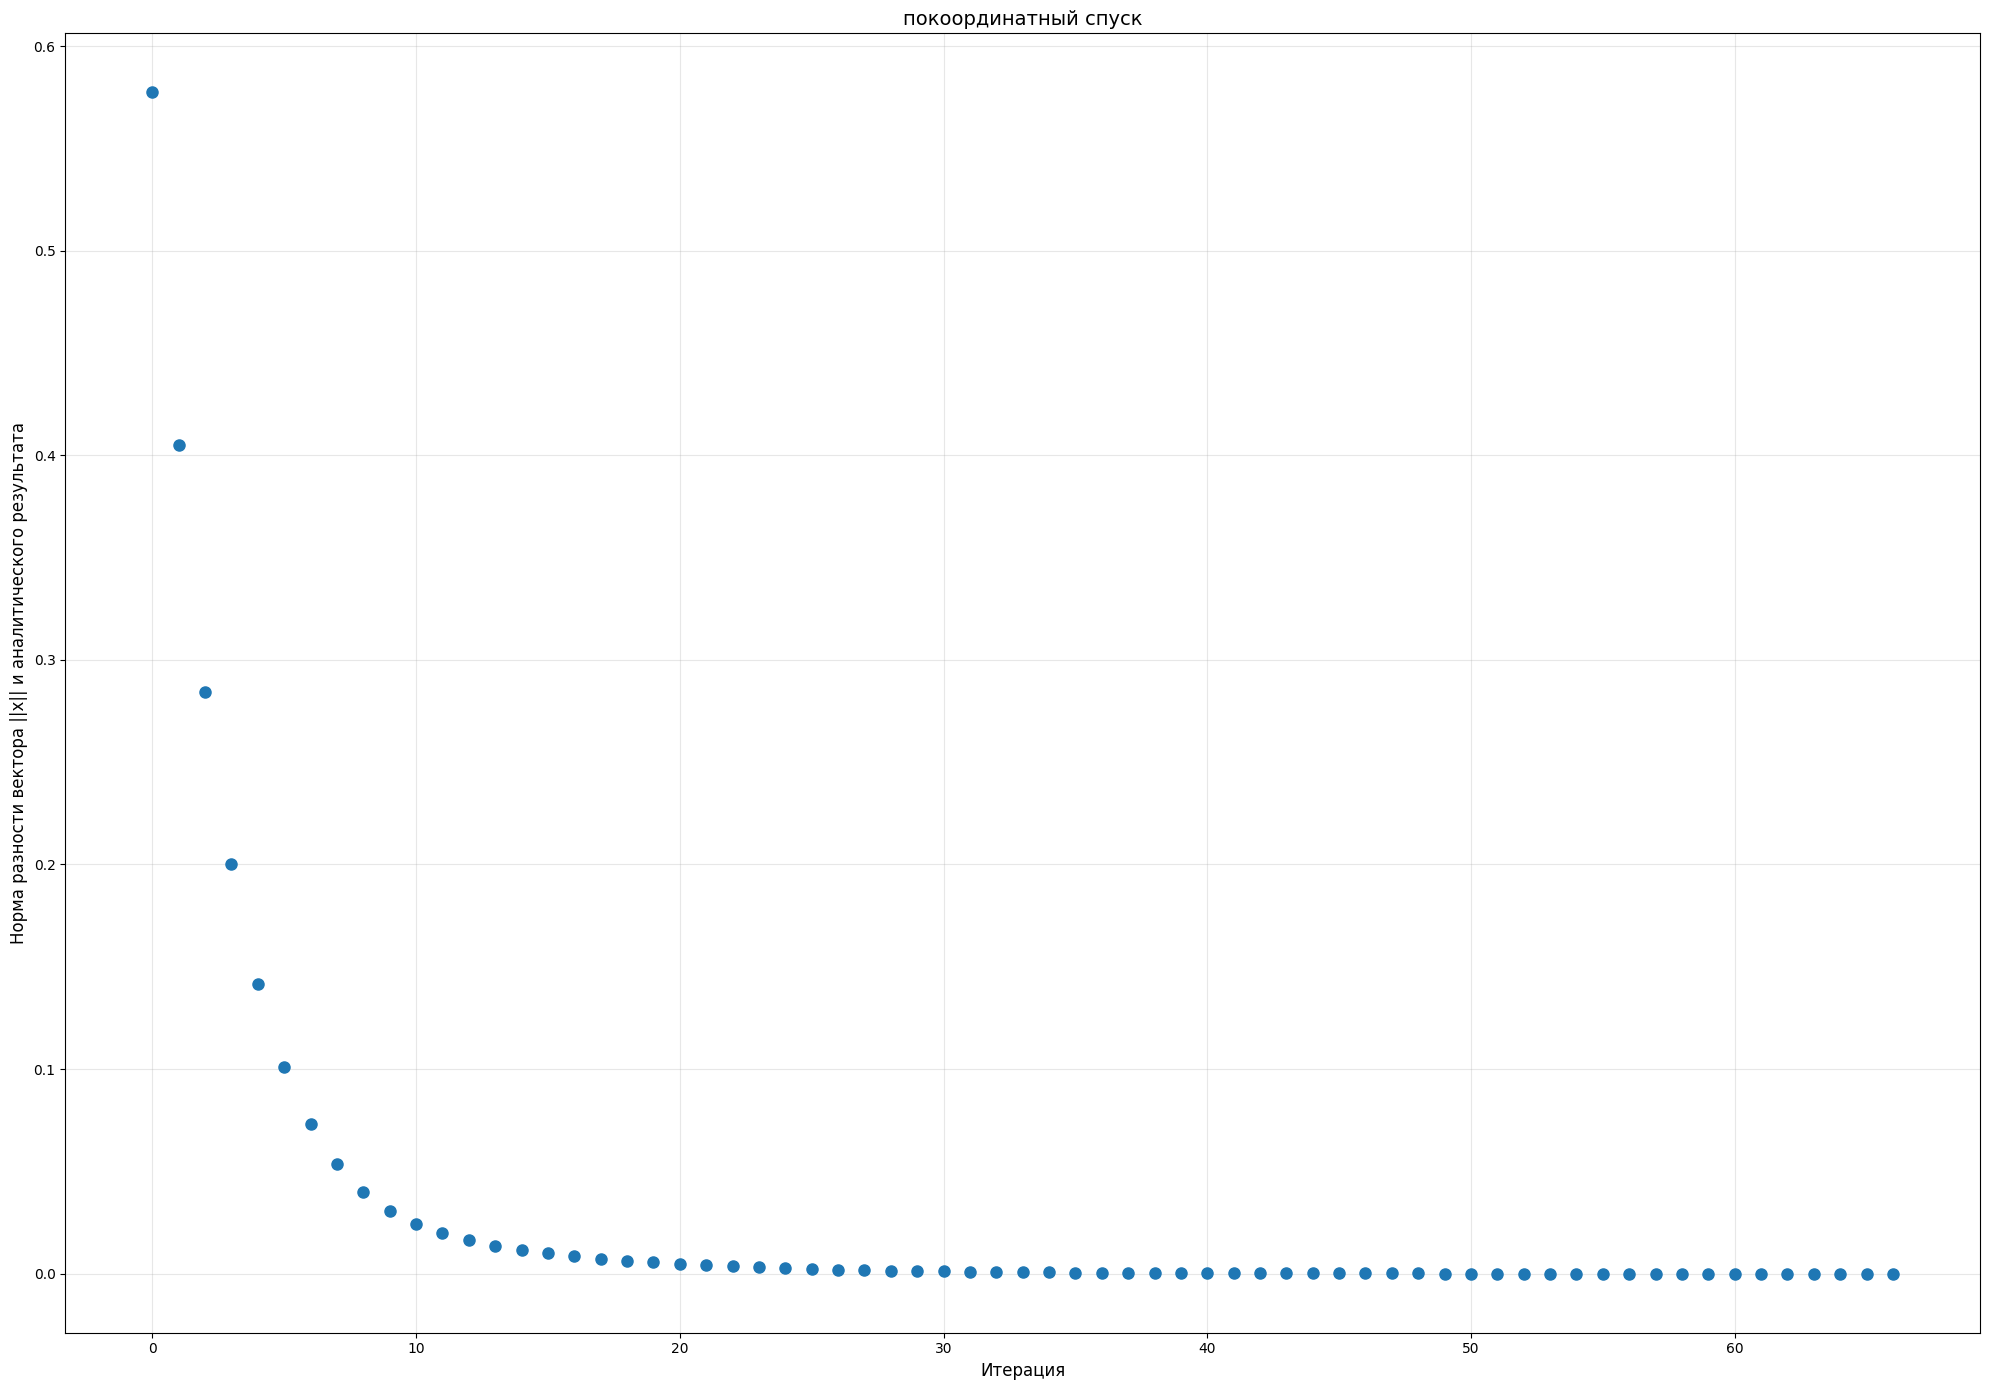

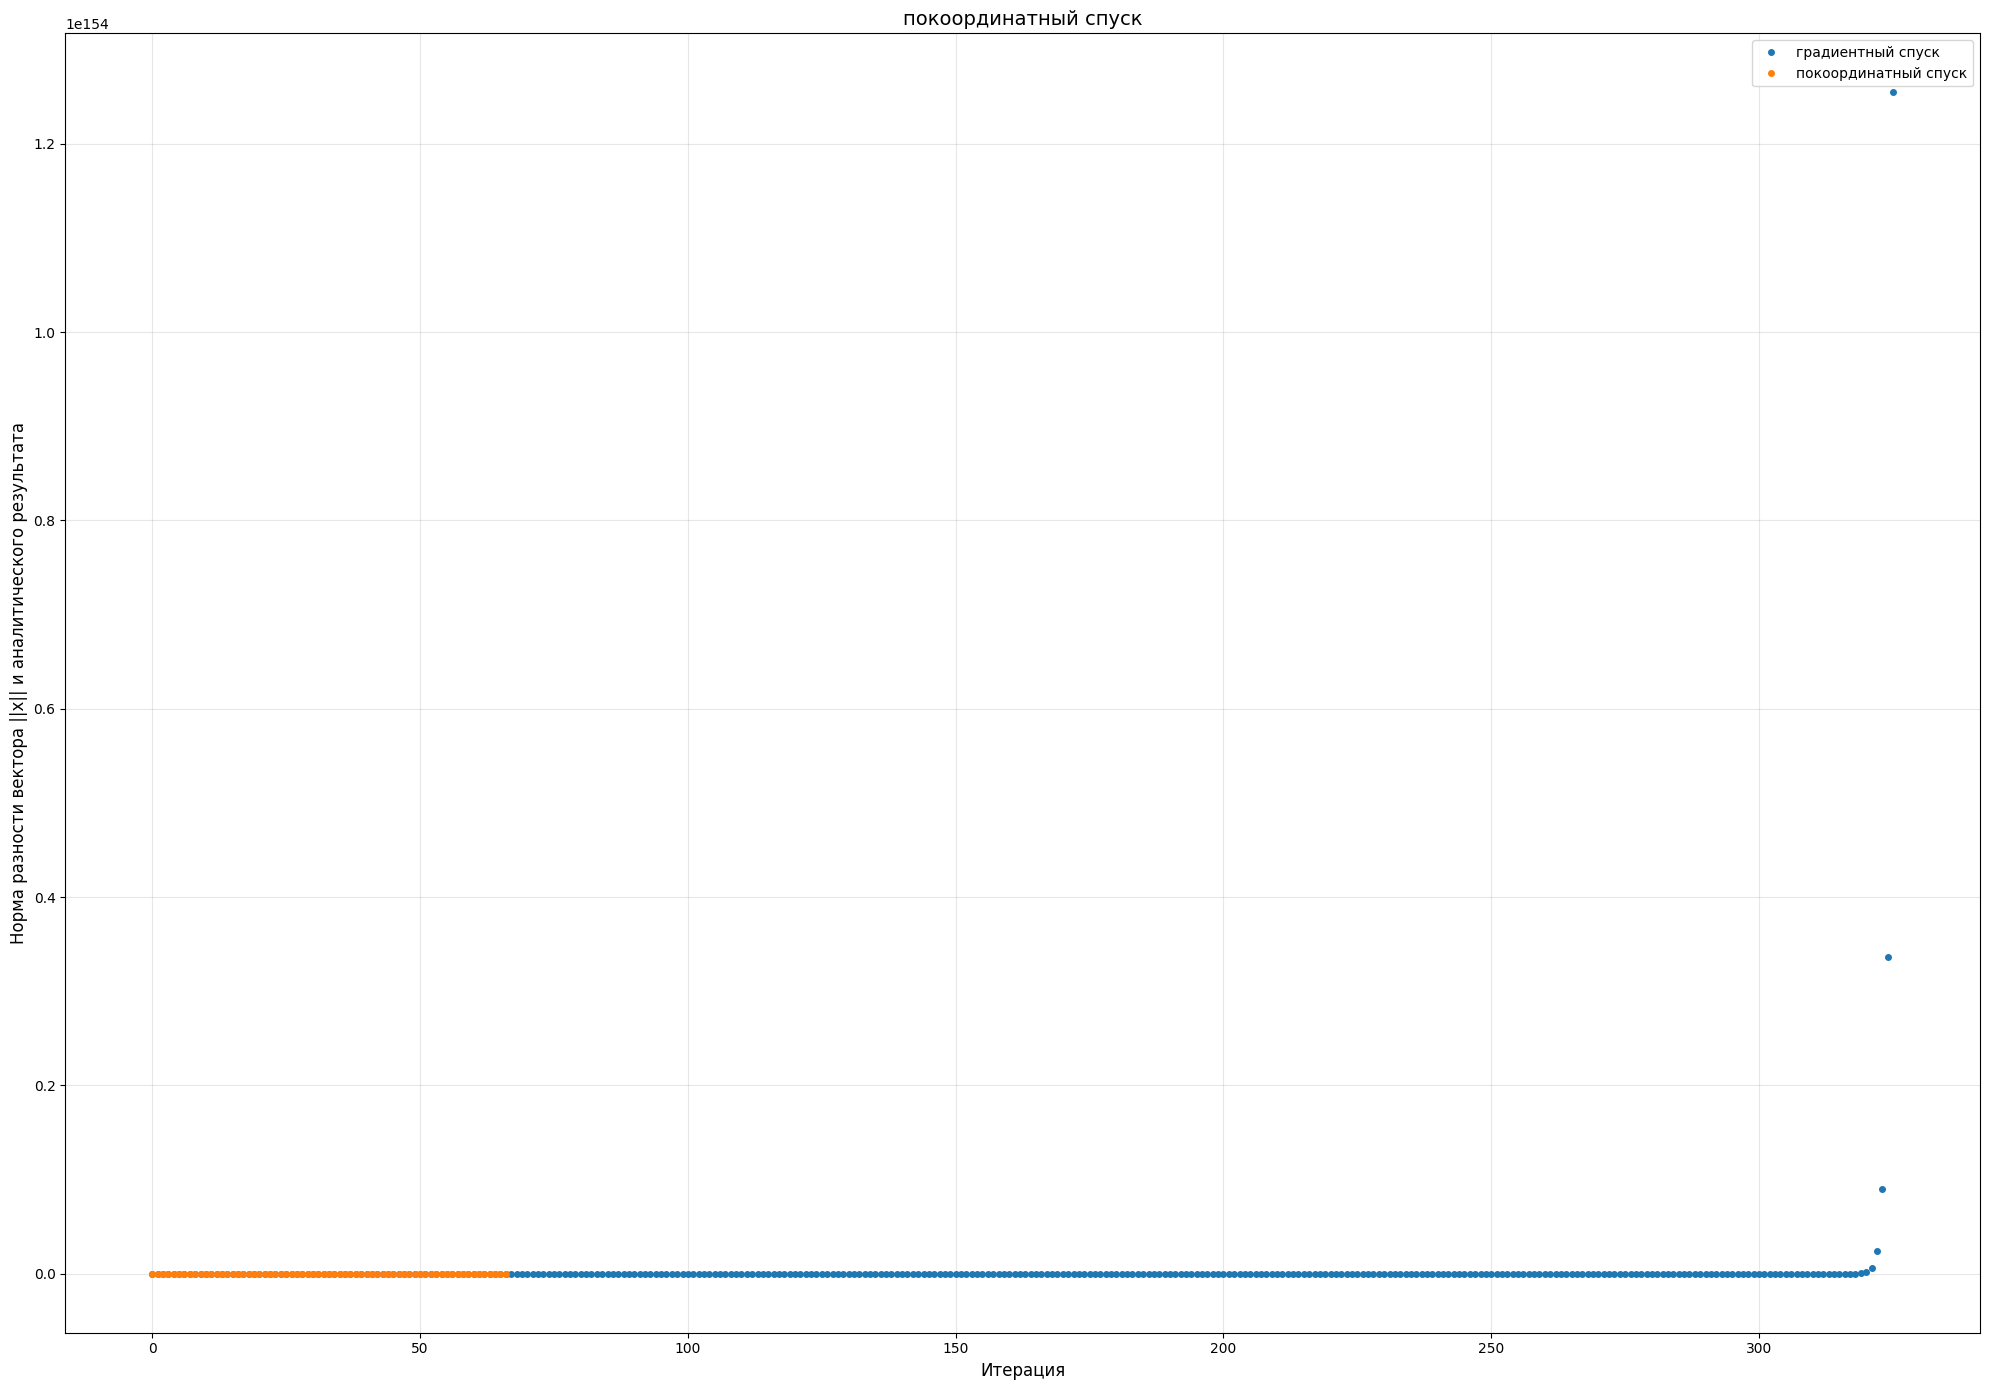

In [128]:
# Задаем матрицу A и вектор b
A = np.array([[4, 1, 0],
                [1, 3, 1],
                [0, 1, 2]], dtype=float)
b = np.array([1, -2, 3], dtype=float)
x0 = np.array([-1,2,-2])
show_results(
    A=A,
    b=b,
    x0=x0,
    tol=1e-6,
    max_iter=1000
)
